# Project 01 (basic) — the internet as a graph

> **Module 16 — ML for Networks 2** - Format: **Jupyter notebook**
>
> **Why this format?** You understand graphs by **looking at them**: plotting degree
> distributions, finding hubs, breaking the network apart. Exploratory analysis with many plots -
> exactly the notebook format (as in modules 02/15).

## Goal
You work with the **real internet topology** (AS level, Oregon route views, March 2001 -
10,670 autonomous systems, 22,002 peerings) and learn:

1. the **degree distribution** and why the internet is **scale-free**,
2. **how to estimate the power-law exponent correctly** - and why the obvious route
   (a log-log fit) is **off by a factor of 2**,
3. **centralities** - who is important, and by which definition,
4. the **robustness** of the internet: harmless against random failures, **fatal** against hub
   attacks,
5. **link prediction** with classical heuristics (common neighbors, Jaccard, **Adamic-Adar**,
   preferential attachment) - including the two traps that ruin such results.

## Prior knowledge
Module 16 script, sections **1** (graph, scale-free, robustness) and **2.1** (heuristics).
`networkx` basics are not required - we introduce them.

## What should work at the end
The reproduction of two famous results **on real data**: the power-law exponent
$\alpha\approx2.1$ (Faloutsos³ 1999) and the robustness asymmetry (Albert/Jeong/Barabási 2000).
Plus a link predictor that is clearly better than chance.

> **This is the solution notebook.** All `# TODO` places are filled in, and the reference answers
> to the mini exercises are at the very end.


In [1]:
import urllib.request, gzip, os, random
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

SEED = 0
rng = np.random.default_rng(SEED)
print("networkx", nx.__version__)


networkx 3.6.1


## 1 - Fetching real data

**Dataset:** `oregon1_010331` from the **SNAP** repository (Stanford) - the AS peering topology
derived from **BGP** data of the Oregon route views of 31 March 2001. A node = an **autonomous
system** (a provider/an organization with its own routing policy), an edge = the two AS **peer**
with each other.

These are **real measurement data** - 69 KB, downloaded in ~1 s, cached locally afterwards.

> **An important caveat** (script 4.4): **nobody** knows the "real" AS topology. Route collectors
> only see what BGP shows them; **peerings between small AS are systematically missing**. So we
> work on an *incomplete, biasedly measured* graph - and that applies to **all** the results
> below.


In [2]:
URL = "https://snap.stanford.edu/data/oregon1_010331.txt.gz"
PATH = "datasets/oregon1_010331.txt.gz"
os.makedirs(os.path.dirname(PATH), exist_ok=True)

if not os.path.exists(PATH):
    req = urllib.request.Request(URL, headers={"User-Agent": "Mozilla/5.0"})  # without UA: 403
    with urllib.request.urlopen(req, timeout=60) as r, open(PATH, "wb") as f:
        f.write(r.read())
    print("downloaded ->", PATH)
else:
    print("already present ->", PATH)

with gzip.open(PATH, "rt") as f:
    lines = [l for l in f if not l.startswith("#")]

G = nx.parse_edgelist(lines, nodetype=int)
print(f"\nGraph: {G.number_of_nodes():,} nodes (AS), {G.number_of_edges():,} edges (peerings)")
print("connected:", nx.is_connected(G))


already present -> datasets/oregon1_010331.txt.gz

Graph: 10,670 nodes (AS), 22,002 edges (peerings)
connected: True


## 2 - First key figures

**Your task:** compute the degree statistics. Pay attention to the ratio of **median vs. mean vs.
maximum** - the same pattern as with the flow sizes in module 15 (a heavy tail).


In [3]:
degrees = np.array([d for _, d in G.degree()])

print(f"Degree  min {degrees.min()} | median {np.median(degrees):.0f} | "
      f"mean {degrees.mean():.2f} | max {degrees.max()}")
print(f"Density: {nx.density(G):.6f}  ({100*nx.density(G):.4f} % of the possible edges)")
print(f"Mean clustering coefficient: {nx.average_clustering(G):.4f}")
print("\n-> Median 2, but a maximum of 2312: there is NO typical degree.")
print("   The mean (4.12) describes nobody - the classic heavy tail.")


Degree  min 1 | median 2 | mean 4.12 | max 2312
Density: 0.000387  (0.0387 % of the possible edges)


Mean clustering coefficient: 0.2970

-> Median 2, but a maximum of 2312: there is NO typical degree.
   The mean (4.12) describes nobody - the classic heavy tail.


## 3 - The degree distribution - and the trap

Plot the degree distribution **doubly logarithmically**. A power law $P(d)\propto d^{-\alpha}$
becomes a **straight line** in the log-log plot - that is the famous Faloutsos³ result (1999).

The **CCDF** (complementary distribution function, $P(D\ge d)$) is the more honest representation
than the histogram: it needs no binning and the tail is less noisy.


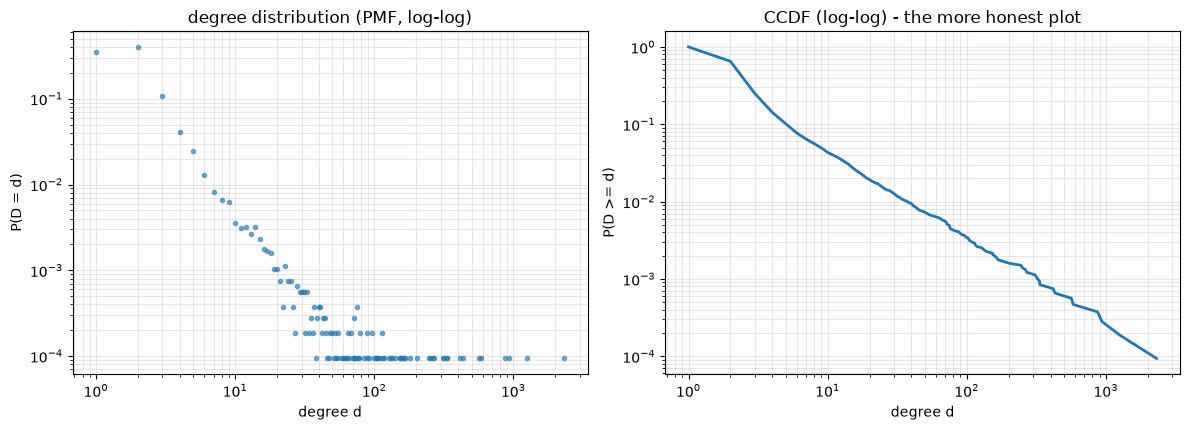

Both ~ a straight line in the log-log plot => power law => scale-free.


In [4]:
values, counts = np.unique(degrees, return_counts=True)
pmf = counts / counts.sum()
ccdf = np.array([(degrees >= w).mean() for w in values])     # P(D >= d)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.4))
ax1.loglog(values, pmf, "o", ms=3, alpha=0.6)
ax1.set(xlabel="degree d", ylabel="P(D = d)", title="degree distribution (PMF, log-log)")
ax2.loglog(values, ccdf, "-", lw=2)
ax2.set(xlabel="degree d", ylabel="P(D >= d)", title="CCDF (log-log) - the more honest plot")
for ax in (ax1, ax2):
    ax.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
print("Both ~ a straight line in the log-log plot => power law => scale-free.")


### 3.1 - Estimating the exponent - correctly and incorrectly

Now the most important methodological point of the project.

**The obvious route:** fit a line through the log-log points (`np.polyfit`), read off the slope.
**That is systematically wrong.** In the tail there are only 0-3 nodes per degree value; their
logarithmized noise is massively biased, and empty bins disappear completely. The least-squares
line gets bent by this.

**The correct route** (Clauset, Shalizi & Newman 2009): the **maximum likelihood estimator**,
applied only to the tail $d\ge d_{\min}$:
$$\hat\alpha = 1 + n\Big[\sum_{i=1}^{n}\ln\frac{d_i}{d_{\min}-\tfrac12}\Big]^{-1}$$

**Your task:** implement both and compare. The literature value for the internet AS topology is
$\alpha\approx 2.1$ - which method hits it?


In [5]:
def alpha_naive(values, counts):
    # Naive log-log fit on the PMF. Returns: the estimated alpha (positive).
    pmf = counts / counts.sum()
    slope = np.polyfit(np.log(values), np.log(pmf), 1)[0]
    return -slope

def alpha_mle(degrees, d_min):
    # Clauset MLE on the tail d >= d_min.
    x = degrees[degrees >= d_min].astype(float)
    return 1 + len(x) / np.sum(np.log(x / (d_min - 0.5)))

print(f"naive log-log fit : alpha = {alpha_naive(values, counts):.2f}   <-- WRONG")
for d_min in (1, 2, 5, 10):
    print(f"MLE (d_min={d_min:2d})    : alpha = {alpha_mle(degrees, d_min):.2f}  "
          f"(n={int((degrees >= d_min).sum())})")
print("\nLiterature value for internet AS: alpha ~ 2.1")
print("-> The MLE hits it (2.08-2.12 for d_min>=5); the naive fit lands at ~1.1")
print("   and is therefore off by a FACTOR OF 2. Exactly this error appears in many papers.")


naive log-log fit : alpha = 1.14   <-- WRONG
MLE (d_min= 1)    : alpha = 1.72  (n=10670)
MLE (d_min= 2)    : alpha = 2.51  (n=6950)
MLE (d_min= 5)    : alpha = 2.12  (n=1084)
MLE (d_min=10)    : alpha = 2.08  (n=462)

Literature value for internet AS: alpha ~ 2.1
-> The MLE hits it (2.08-2.12 for d_min>=5); the naive fit lands at ~1.1
   and is therefore off by a FACTOR OF 2. Exactly this error appears in many papers.


## 4 - Who is important? Centralities

Different definitions of "important" - with very different costs:
- **Degree**: many neighbours (cheap, local).
- **Betweenness**: on how many shortest paths do I lie? (**the bottleneck**) - expensive,
  $O(|V||E|)$, hence sampled here (`k=200`).
- **PageRank**: what matters is who has important neighbours (recursively).

Given - runs in ~10 s.


In [6]:
degree_c = dict(G.degree())
btw = nx.betweenness_centrality(G, k=200, seed=SEED)   # sampled: exact would be too expensive
pr = nx.pagerank(G)

def top(d, k=5):
    return sorted(d.items(), key=lambda t: -t[1])[:k]

print("Top 5 by degree     :", [(as_, g) for as_, g in top(degree_c)])
print("Top 5 by betweenness:", [(as_, round(v, 4)) for as_, v in top(btw)])
print("Top 5 by PageRank   :", [(as_, round(v, 5)) for as_, v in top(pr)])

overlap = len(set(dict(top(degree_c, 20)).keys()) & set(dict(top(btw, 20)).keys()))
print(f"\nOverlap of the top 20 (degree vs. betweenness): {overlap}/20")
print("-> In the internet the measures correlate strongly: the big hubs ARE the bottlenecks.")


Top 5 by degree     : [(701, 2312), (1239, 1259), (7018, 936), (3561, 871), (209, 581)]
Top 5 by betweenness: [(701, 0.3497), (1239, 0.1537), (3561, 0.1143), (7018, 0.0905), (3257, 0.0777)]
Top 5 by PageRank   : [(701, 0.04838), (1239, 0.0255), (7018, 0.01916), (3561, 0.01705), (209, 0.01171)]

Overlap of the top 20 (degree vs. betweenness): 16/20
-> In the internet the measures correlate strongly: the big hubs ARE the bottlenecks.


## 5 - Robustness - the most famous network result

**Albert, Jeong & Barabási (2000, Nature):** scale-free networks are **robust against random
failures**, but **fragile against targeted attacks on hubs**.

**Your task:** remove nodes step by step - once **at random** (routers fail, a digger cuts a
cable), once **targeted by degree** (an attacker goes for the largest AS) - and measure the share
of nodes in the **largest connected component**.


In [7]:
def largest_component_fraction(H, n_original):
    # Share of the nodes in the largest connected component.
    if H.number_of_nodes() == 0:
        return 0.0
    return len(max(nx.connected_components(H), key=len)) / n_original

n0 = G.number_of_nodes()
by_degree = [k for k, _ in sorted(G.degree(), key=lambda t: -t[1])]   # hubs first
random_order = list(G.nodes()); random.Random(SEED).shuffle(random_order)

fractions = np.linspace(0, 0.10, 11)
curve_random, curve_attack = [], []
for f in fractions:
    k = int(f * n0)
    Hr = G.copy(); Hr.remove_nodes_from(random_order[:k])
    Ha = G.copy(); Ha.remove_nodes_from(by_degree[:k])
    curve_random.append(largest_component_fraction(Hr, n0))
    curve_attack.append(largest_component_fraction(Ha, n0))

for f, z, a in zip(fractions, curve_random, curve_attack):
    print(f"{100*f:5.1f}% removed | random {z:.3f} | targeted {a:.3f}")


  0.0% removed | random 1.000 | targeted 1.000
  1.0% removed | random 0.989 | targeted 0.413
  2.0% removed | random 0.976 | targeted 0.155
  3.0% removed | random 0.965 | targeted 0.034
  4.0% removed | random 0.951 | targeted 0.009
  5.0% removed | random 0.939 | targeted 0.003
  6.0% removed | random 0.926 | targeted 0.003
  7.0% removed | random 0.911 | targeted 0.002
  8.0% removed | random 0.883 | targeted 0.001
  9.0% removed | random 0.842 | targeted 0.001
 10.0% removed | random 0.800 | targeted 0.001


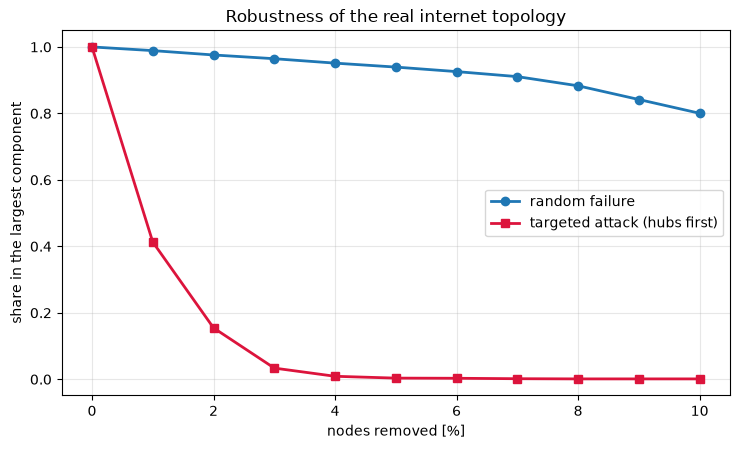

At 5 % removed:  random 0.939  vs.  targeted 0.003
At 10 % removed: random 0.800  vs.  targeted 0.001
-> Remove 5 % of the HUBS and the internet crumbles to dust (0.3 %),
   while 10 % RANDOM failures barely bother it (0.80).
   That is the direct consequence of the scale-free structure.


In [8]:
plt.figure(figsize=(7.5, 4.6))
plt.plot(100*fractions, curve_random, "o-", lw=2, label="random failure")
plt.plot(100*fractions, curve_attack, "s-", lw=2, color="crimson",
         label="targeted attack (hubs first)")
plt.xlabel("nodes removed [%]"); plt.ylabel("share in the largest component")
plt.title("Robustness of the real internet topology"); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"At 5 % removed:  random {curve_random[5]:.3f}  vs.  targeted {curve_attack[5]:.3f}")
print(f"At 10 % removed: random {curve_random[10]:.3f}  vs.  targeted {curve_attack[10]:.3f}")
print("-> Remove 5 % of the HUBS and the internet crumbles to dust (0.3 %),")
print("   while 10 % RANDOM failures barely bother it (0.80).")
print("   That is the direct consequence of the scale-free structure.")


## 6 - Link prediction: which peerings are missing?

**The task:** the measured graph is incomplete. Which edges *ought* to exist? The charm: this
needs **no labels** - the graph labels itself.

**The procedure:** remove 10 % of the edges (= the **positive** test examples), draw an equal
number of non-existent pairs (= the **negative** ones), and check whether heuristics separate
them.

> **Trap 1 (leakage):** the heuristics are computed on the remaining graph $G_{\text{train}}$ -
> **after** the test edges have been removed. If you computed them on the full $G$, common
> neighbors would already "see" the edge you are looking for: the results would be magnificent
> and completely worthless (script 2.5).


In [9]:
edges = list(G.edges())
random.Random(SEED).shuffle(edges)
n_test = int(0.10 * len(edges))
test_pos = edges[:n_test]

# IMPORTANT: remove the test edges BEFORE any features are computed
G_train = G.copy()
G_train.remove_edges_from(test_pos)
print(f"G_train: {G_train.number_of_edges():,} edges "
      f"({n_test:,} removed for testing)")

# an equal number of NON-existent pairs as negative examples
nodes = list(G.nodes())
test_neg, seen = [], set()
while len(test_neg) < n_test:
    u, v = random.Random(SEED + len(test_neg)).sample(nodes, 2)
    if u != v and not G.has_edge(u, v) and (u, v) not in seen:
        seen.add((u, v)); test_neg.append((u, v))
print(f"Negative examples: {len(test_neg):,}")


G_train: 19,802 edges (2,200 removed for testing)
Negative examples: 2,200


### 6.1 - The heuristics

**Your task:** implement the four classical measures. With $N(u)$ = the neighbours of $u$ in the
**training graph**:

| Heuristic | Formula |
|---|---|
| Common neighbors | $\|N(u)\cap N(v)\|$ |
| Jaccard | $\frac{\|N(u)\cap N(v)\|}{\|N(u)\cup N(v)\|}$ |
| **Adamic-Adar** | $\sum_{w\in N(u)\cap N(v)}\frac{1}{\log d_w}$ |
| Preferential attachment | $d_u\cdot d_v$ |

*(Careful with Adamic-Adar: $\log d_w$ can be 0 if $d_w=1$ -> catch the division by zero.)*


In [10]:
def neighbors(H, u):
    return set(H[u]) if u in H else set()

def common_neighbors(H, u, v):
    return len(neighbors(H, u) & neighbors(H, v))

def jaccard(H, u, v):
    a, b = neighbors(H, u), neighbors(H, v)
    union = a | b
    return len(a & b) / len(union) if union else 0.0

def adamic_adar(H, u, v):
    s = 0.0
    for w in neighbors(H, u) & neighbors(H, v):
        d = H.degree(w)
        if d > 1:                      # log(1) = 0 -> skip
            s += 1.0 / np.log(d)
    return s

def preferential_attachment(H, u, v):
    return (H.degree(u) if u in H else 0) * (H.degree(v) if v in H else 0)


In [11]:
from sklearn.metrics import roc_auc_score, average_precision_score

HEURISTICS = {
    "Common neighbors": common_neighbors,
    "Jaccard": jaccard,
    "Adamic-Adar": adamic_adar,
    "Preferential attachment": preferential_attachment,
}

y = np.r_[np.ones(len(test_pos)), np.zeros(len(test_neg))]
pairs = test_pos + test_neg

print(f"{'Heuristic':26s} {'ROC-AUC':>9s} {'PR-AUC':>8s}")
for name, fn in HEURISTICS.items():
    s = np.array([fn(G_train, u, v) for u, v in pairs])
    print(f"{name:26s} {roc_auc_score(y, s):9.4f} {average_precision_score(y, s):8.4f}")
print("\n(Chance would be ROC-AUC 0.5 and PR-AUC 0.5 - the test set is 1:1 balanced.)")
print("A surprise: preferential attachment wins?! Let us look at that more closely...")


Heuristic                    ROC-AUC   PR-AUC
Common neighbors              0.7191   0.7123
Jaccard                       0.6984   0.6121
Adamic-Adar                   0.7235   0.7320
Preferential attachment       0.7632   0.8566

(Chance would be ROC-AUC 0.5 and PR-AUC 0.5 - the test set is 1:1 balanced.)
A surprise: preferential attachment wins?! Let us look at that more closely...


### 6.2 - Trap 3: the degree confound

**Preferential attachment** - the *dumbest* of the four heuristics (it only looks at the degrees
and ignores the neighbourhood entirely) - has just **won**. That should make you suspicious.

**The suspicion:** our **negative** examples are node pairs drawn *uniformly at random*. In a
scale-free graph a random node is almost certainly a **leaf** (median degree 2!) - so a random
pair is almost always **leaf × leaf**. Real edges, by contrast, involve **hubs**
disproportionately often. So PA does not have to recognize any "structure" at all: it simply
distinguishes *hub involved* from *leaf×leaf*. Let us check that.


In [12]:
degree_product = lambda prs: np.array([G.degree(u) * G.degree(v) for u, v in prs])
print("Median of the degree product d_u * d_v:")
print(f"  real edges (positive)  : {np.median(degree_product(test_pos)):>8.0f}")
print(f"  random pairs (negative): {np.median(degree_product(test_neg)):>8.0f}")
print("  -> a factor of >100 difference. PA separates the two groups almost trivially,")
print("     without knowing anything about the actual neighbourhood.\n")

# The counter-check: DEGREE-MATCHED negative examples.
# For every real edge (u0,v0) we draw a NON-pair with degrees as equal as possible.
_rnd = random.Random(SEED)
bins = {}
for k, d in G.degree():
    bins.setdefault(d, []).append(k)
degree_values = np.array(sorted(bins))

def draw_node_with_degree(d):
    g = int(degree_values[np.argmin(np.abs(degree_values - d))])
    return _rnd.choice(bins[g])

neg_matched = []
for (u0, v0) in test_pos:
    du, dv = G.degree(u0), G.degree(v0)
    for _ in range(40):
        u, v = draw_node_with_degree(du), draw_node_with_degree(dv)
        if u != v and not G.has_edge(u, v):
            neg_matched.append((u, v)); break

print(f"degree-matched negative examples: {len(neg_matched):,}")
print(f"Median degree product now: positive {np.median(degree_product(test_pos)):.0f} | "
      f"negative {np.median(degree_product(neg_matched)):.0f}  <- comparable now\n")

y2 = np.r_[np.ones(len(test_pos)), np.zeros(len(neg_matched))]
pairs2 = test_pos + neg_matched
print(f"{'Heuristic':26s} {'uniform':>9s} {'degree-matched':>15s}")
for name, fn in HEURISTICS.items():
    s1 = np.array([fn(G_train, u, v) for u, v in pairs])
    s2 = np.array([fn(G_train, u, v) for u, v in pairs2])
    print(f"{name:26s} {roc_auc_score(y, s1):9.4f} {roc_auc_score(y2, s2):15.4f}")


Median of the degree product d_u * d_v:
  real edges (positive)  :      500
  random pairs (negative):        4
  -> a factor of >100 difference. PA separates the two groups almost trivially,
     without knowing anything about the actual neighbourhood.

degree-matched negative examples: 2,139
Median degree product now: positive 500 | negative 420  <- comparable now

Heuristic                    uniform  degree-matched
Common neighbors              0.7191          0.5589
Jaccard                       0.6984          0.5653


Adamic-Adar                   0.7235          0.5660
Preferential attachment       0.7632          0.4057


**The result is unambiguous - and an object lesson:**

| Heuristic | uniform negatives | **degree-matched** |
|---|---|---|
| Common neighbors | 0.719 | 0.559 |
| Jaccard | 0.698 | 0.565 |
| **Adamic-Adar** | 0.724 | **0.566** ← now the best |
| **Preferential attachment** | **0.763** ← "the winner" | **0.406** ← worse than guessing! |

**Preferential attachment crashes from 0.763 to 0.406** - i.e. down to chance level and below.
Its entire "lead" was **not a signal but an artifact of the negative sampling**. As soon as the
positive and negative pairs have the same degree distribution, **nothing** of PA remains, and
**Adamic-Adar** is the best heuristic, as expected.

At the same time *all* methods drop to ~0.56: **the task is in truth far harder** than the first
table suggested.

> **The lesson:** it is not only the *model* that can deceive - the **construction of the test
> set** already decides what you measure. Uniformly drawn negative examples are the standard in
> countless link prediction papers. To a large extent they measure only whether a method can read
> degrees. Together with the base rate trap (below) this means: **link prediction numbers from
> the literature should be taken with great caution.**


## 7 - Conclusion

**What you have reproduced - on real data:**
1. **Scale-free**: median degree 2, but a hub with **2312** neighbours. No typical degree.
2. **The exponent**: MLE ≈ **2.08-2.12** (= the literature value ~2.1 ✓), naive log-log fit
   ≈ **1.1** - **off by a factor of 2**. The convenient method is the wrong one.
3. **Robustness**: 10 % random failure → 80 % stay connected. **5 % targeted → 0.3 %.**
   The same structure that immunizes the internet against mishaps makes it fragile against
   attackers.
4. **Link prediction** works without any label - **Adamic-Adar** is the strongest heuristic,
   because its weighting $1/\log d_w$ does exactly the right thing: a common neighbour of
   degree 3 is strong evidence, a tier-1 hub of degree 2000 (which *everybody* is connected to)
   says almost nothing.

> ### Trap 2: the base rate - once again
> Our test set is **1:1 balanced** (as many positive as negative pairs). Convenient - but
> **reality** is: 22,002 edges among **57 million** possible pairs, i.e.
> $\pi\approx 3.9\cdot10^{-4}$. By the **base-rate fallacy** (module 15!) a ROC-AUC of 0.95 on
> balanced data means, in real deployment - trying all pairs - **almost nothing but false
> alarms**. Balanced sampling is standard in the literature; you just have to say honestly what
> it does **not** show.

### Mini exercises
1. Compute the true base rate $\pi$ and use the Bayes formula from module 15 (P02) to estimate
   the **PPV** of Adamic-Adar at a realistic operating point. Sobering?
2. Compute the heuristics **on the full `G`** instead of on `G_train` (i.e. with leakage) - how
   fantastic do the numbers get?
3. Remove only 1 % of the edges instead of 10 %. Do the heuristics get better? Why?
4. Compare the robustness curve with a **random graph** of the same node/edge count
   (`nx.gnm_random_graph`). Does the asymmetry disappear? (That is the actual proof that it comes
   from the **scale-free structure**.)

---

### Reference answers to the mini exercises

*(All numbers measured on this graph with `SEED = 0`; run the experiments yourself - the point is
the pattern, not the fourth decimal.)*

**1. Base rate and PPV.** With $n=10{,}670$ nodes there are $\binom{n}{2}=56{,}919{,}115$
possible pairs and 22,002 real edges, so $\pi = 3.87\cdot10^{-4}$. Adamic-Adar is only non-zero
when there is at least one common neighbour; that holds for 49.0 % of the real edges but also for
6.5 % of the random pairs. So the rule "AA > 0" means TPR = 0.490, FPR = 0.0655, and Bayes gives
$$P(\text{edge}\mid\text{alarm})=\frac{0.490\cdot3.87\cdot10^{-4}}{0.490\cdot3.87\cdot10^{-4}+0.0655\cdot(1-3.87\cdot10^{-4})}=\mathbf{0.29\,\%}.$$
In absolute terms: about 10,800 correctly found edges against **3.7 million** false suggestions.
Even at the strictest useful threshold (TPR 0.137, FPR $4.5\cdot10^{-4}$) the PPV only reaches
**10.4 %** - nine out of ten proposals are still wrong. And that is the *optimistic* estimate,
because the FPR was measured on uniformly drawn pairs (the degree confound, see exercise 4 of the
main part). This is the base-rate fallacy from module 15, one to one: a ROC-AUC of 0.72 sounds
usable, in deployment it is a flood of false alarms.

**2. Leakage.** If the heuristics are computed on the full `G`, the ROC-AUC rises for all of them
- but by strikingly different amounts: common neighbors 0.719 → 0.741, Jaccard 0.698 → 0.712,
Adamic-Adar 0.724 → 0.747, and **preferential attachment 0.763 → 0.966**. The reason for the
enormous jump of PA: in the full graph the degrees $d_u,d_v$ still contain the test edge itself,
which raises the degree of both endpoints by exactly 1 - for a leaf of degree 1 that is a doubling.
The neighbourhood-based measures gain less because one common neighbour more or less matters less.
The lesson: leakage does not inflate all methods equally, it inflates precisely the ones that read
the leaked quantity most directly - so it also **distorts the ranking**, not only the level.

**3. 1 % instead of 10 % test edges.** All heuristics get slightly better: CN 0.719 → 0.736,
Jaccard 0.698 → 0.706, AA 0.724 → 0.744, PA 0.763 → 0.774. The reason is not that the task became
easier for the model but that `G_train` stays **more complete**: with 10 % removed, 2,200 edges are
missing from the neighbourhood computation, and for the test edge $(u,v)$ its common neighbours may
themselves have been removed. With 1 % the graph you compute on is almost the full one. Careful
with the interpretation: better numbers at a smaller test share are **not** evidence of a better
method - they mostly measure how much graph you left in. It is also the transition to the leakage
case from exercise 2: at 0 % removed you would be measuring pure memorization.

**4. The random graph.** `nx.gnm_random_graph(10670, 22002)` has the same size, but a completely
different degree distribution: maximum degree **14** instead of 2312, median 4 instead of 2. And
the asymmetry disappears almost entirely:

| removed | real AS graph (random / targeted) | random graph (random / targeted) |
|---|---|---|
| 5 % | 0.939 / **0.003** | 0.932 / **0.922** |
| 10 % | 0.800 / **0.001** | 0.878 / **0.858** |

In the random graph, a targeted attack is barely worse than a random failure (0.922 vs. 0.932) -
because there are no hubs whose removal could tear thousands of edges down. This is the actual
proof of the causal claim: the fragility does not come from the size or the density of the graph
but **from the scale-free degree distribution**. Incidentally the random graph is *more* robust
against targeted attacks than the real internet - the price it pays is that it does not exist:
real networks grow by preferential attachment and therefore produce hubs.
